In [2]:
import csv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from hurst import compute_Hc
from arch.unitroot import VarianceRatio
from sklearn.linear_model import LinearRegression

ROUND_NUM = 5
BASE = 'round5'
DAYS = ['2', '3', '4']
robots = ['ROBOT_VACUUMING', 'ROBOT_MOPPING', 'ROBOT_DISHES', 'ROBOT_LAUNDRY', 'ROBOT_IRONING']

price_rows = []
offset = 0
for day in DAYS:
    with open(f'./{BASE}/prices_round_{ROUND_NUM}_day_{day}.csv') as f:
        for row in csv.DictReader(f, delimiter=';'):
            mid = row['mid_price']
            if row['product'] not in robots or not mid or float(mid) == 0:
                continue
            row['timestamp'] = int(row['timestamp']) + offset
            price_rows.append(row)
    offset += 1_000_000

prices = pd.DataFrame(price_rows)
for col in ['timestamp', 'bid_price_1', 'bid_volume_1', 'ask_price_1', 'ask_volume_1', 'mid_price']:
    prices[col] = pd.to_numeric(prices[col], errors='coerce')

del price_rows
del offset
del col
del day
del f
del row
del mid
prices.head()

,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss
0,2,0,ROBOT_DISHES,9996,14,,,,,10004,14,,,,,10000.0,0.0
1,2,0,ROBOT_VACUUMING,9996,14,,,,,10004,14,,,,,10000.0,0.0
2,2,0,ROBOT_MOPPING,9996,14,,,,,10004,14,,,,,10000.0,0.0
3,2,0,ROBOT_LAUNDRY,9996,14,,,,,10004,14,,,,,10000.0,0.0
4,2,0,ROBOT_IRONING,9996,14,,,,,10004,14,,,,,10000.0,0.0


In [3]:
#prices = prices[prices["product"].isin(robots)].copy()
chores = [s.split('_')[1] for s in robots]
bot = lambda s: prices[prices['product'] == f'ROBOT_{s}']

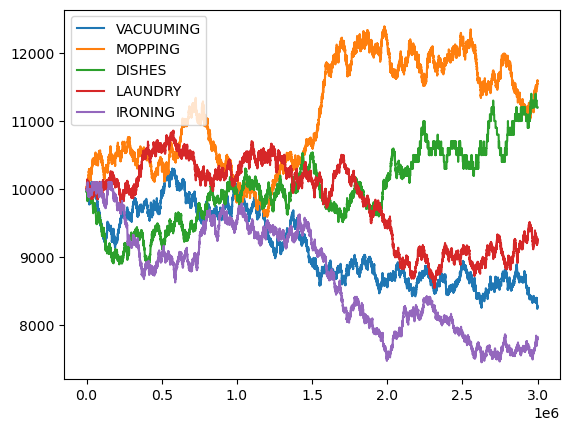

In [4]:
for p in chores:
    plt.plot(bot(p).timestamp, bot(p).mid_price, label=p)
plt.legend()
plt.show()

In [5]:
mids = prices.pivot_table(
    index="timestamp",
    columns="product",
    values="mid_price",
).sort_index()
#mids

<Axes: title={'center': 'Average mid across all ROBOTS'}, xlabel='timestamp'>

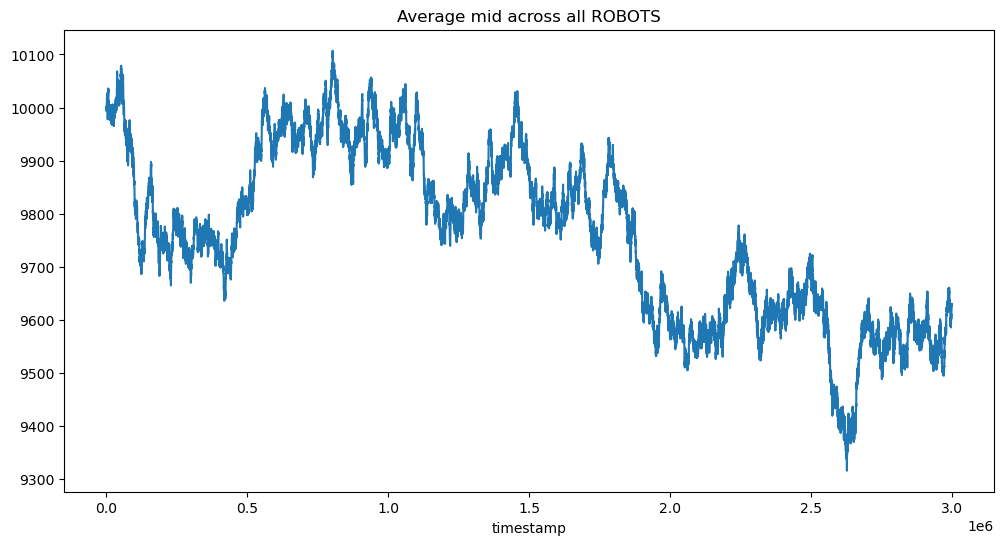

In [6]:
#pebble_cols = [c for c in mids.columns if c.startswith("ROBOT_")]
mids["ROBOT_avg"] = mids[robots].mean(axis=1)
mids["ROBOT_avg"].plot(figsize=(12, 6), title="Average mid across all ROBOTS")

MOPPING
count    29999.000000
mean         0.052918
std         11.145534
min        -43.000000
25%         -7.500000
50%          0.000000
75%          7.500000
max         46.500000
Name: mid_price, dtype: float64


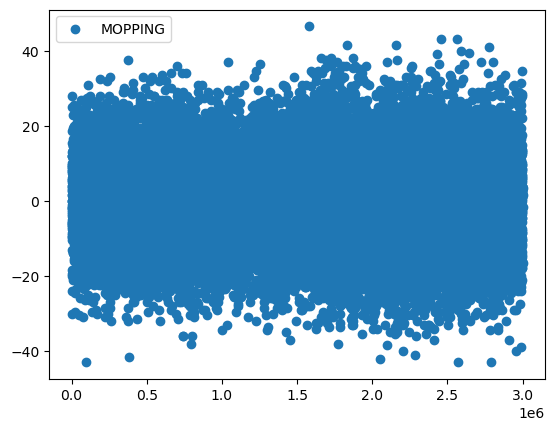

In [7]:
for p in chores[1:2]:
    y = bot(p).mid_price.diff()
    x = bot(p).timestamp
    plt.scatter(x, y, label=p)
    print(p)
    print(y.describe())
plt.legend()
plt.show()

In [8]:
assets = chores
for asset in assets[0:1]:
    tmp = bot(asset).mid_price
    log_returns = np.diff(np.log(tmp))
    diff = np.diff(tmp)
    
    # GBM in log space should be iid Gaussian
    print(f"Asset {asset}:")
    print(f"  ADF on levels: {adfuller(tmp)[1]:.4f}")  # should NOT reject
    print(f"  ADF on log-returns: {adfuller(log_returns)[1]:.4f}")  # should reject
    print(f"  Ljung-Box on log-returns:\n {acorr_ljungbox(log_returns, lags=5)}")  # should be white noise
    print(f"  Hurst: {compute_Hc(tmp)}")  # should be ~0.5
    print(f"  Skewness of log-returns: {stats.skew(log_returns):.4f}")
    print(f"  Excess kurtosis of log-returns: {stats.kurtosis(log_returns):.4f}")

Asset VACUUMING:
  ADF on levels: 0.5652
  ADF on log-returns: 0.0000
  Ljung-Box on log-returns:
     lb_stat  lb_pvalue
1  1.863221   0.172254
2  2.350002   0.308819
3  4.647415   0.199512
4  4.721869   0.317044
5  4.908858   0.427104
  Hurst: (np.float64(0.4959126763386021), np.float64(1.429842215894076), [[10, 17, 31, 56, 100, 177, 316, 562, 1000, 1778, 3162, 5623, 10000, 17782, 30000], [np.float64(3.9868321890314684), np.float64(5.425648968007118), np.float64(7.593728460897337), np.float64(10.632233514939552), np.float64(14.729781715912974), np.float64(19.891151466708486), np.float64(26.837007184218464), np.float64(35.333043473719464), np.float64(48.63994063438015), np.float64(63.93822503685278), np.float64(79.03906960443265), np.float64(96.48092884235534), np.float64(124.8002817823049), np.float64(178.83362639925812), np.float64(223.09726684760668)]])
  Skewness of log-returns: -0.0076
  Excess kurtosis of log-returns: 0.0192


## What kinds of driftless processes are these?
VACUUMING: Is a GBM  
MOPPING: Is autoregressive/momentum -- check ACF/PACF  
DISHES: Very weird. It is homoskedastic until the last 1/3 (basically day 4) where the log returns get pulled from either of two satellite distributions symmetrically around the main one (see plots below). Whatever strategy we use should either be robust to a sudden volatility spike or we should have one strategy for when the market is calm and another one for when it is volatile.  
LAUNDRY: Seems to be mean-reverting according to Hurst parameter -- check ACF/PACF  
IRONING: DEFINITELY autoregressive or some shi -- similar phenomenon to DISHES  
  
Further exploration: See if all of these assets exhibit regime shifts and/or if they all do it at the same time.

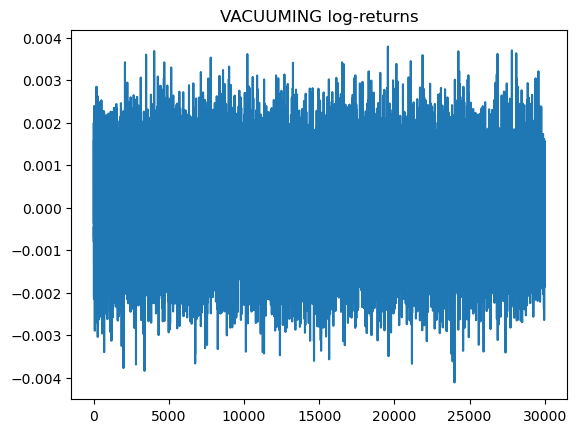

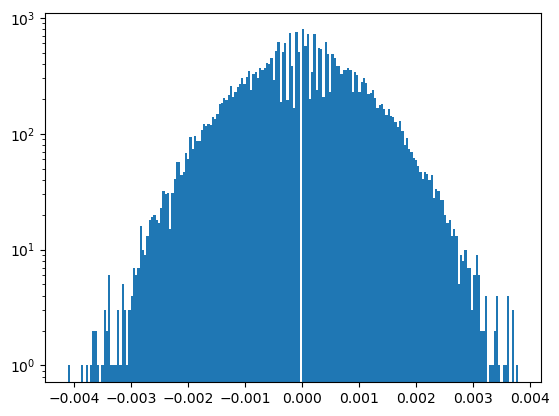

Text(0.5, 1.0, 'Q-Q Plot')

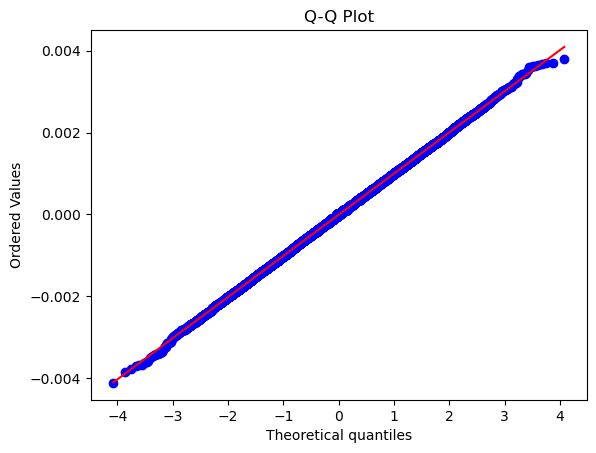

In [9]:
log_ret = np.diff(np.log(bot('VACUUMING').mid_price))
plt.plot(log_ret)
plt.title('VACUUMING log-returns')
plt.show()
# Also look at the distribution
plt.hist(log_ret, bins=200)
plt.yscale('log')  # log scale to see tail behavior
plt.show()
stats.probplot(log_ret, dist="norm", plot=plt)
plt.title('Q-Q Plot')

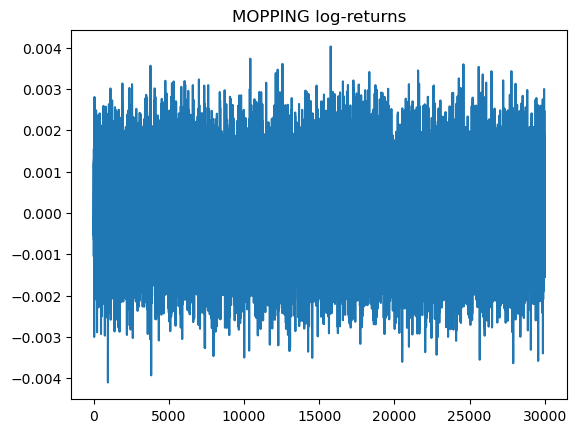

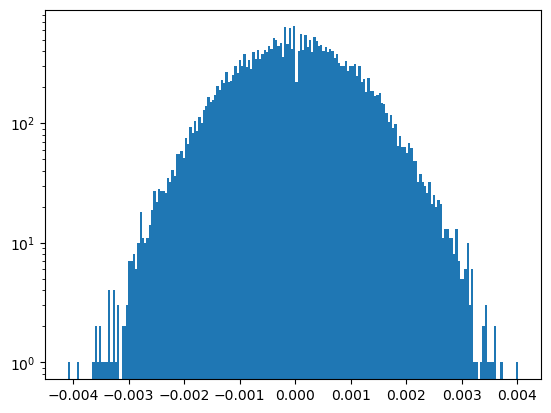

Text(0.5, 1.0, 'Q-Q Plot')

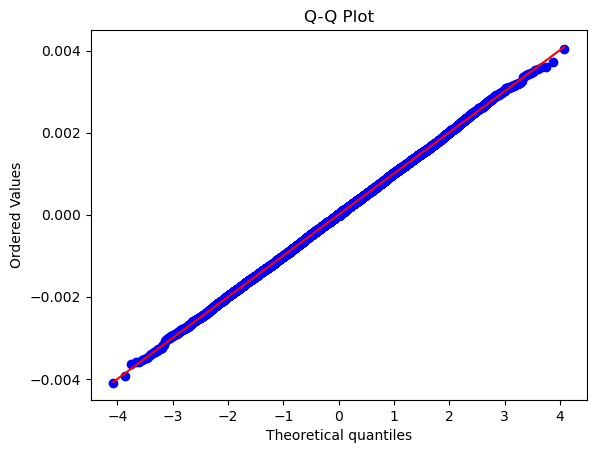

In [10]:
log_ret = np.diff(np.log(bot('MOPPING').mid_price))
plt.plot(log_ret)
plt.title('MOPPING log-returns')
plt.show()
# Also look at the distribution
plt.hist(log_ret, bins=200)
plt.yscale('log')  # log scale to see tail behavior
plt.show()
stats.probplot(log_ret, dist="norm", plot=plt)
plt.title('Q-Q Plot')

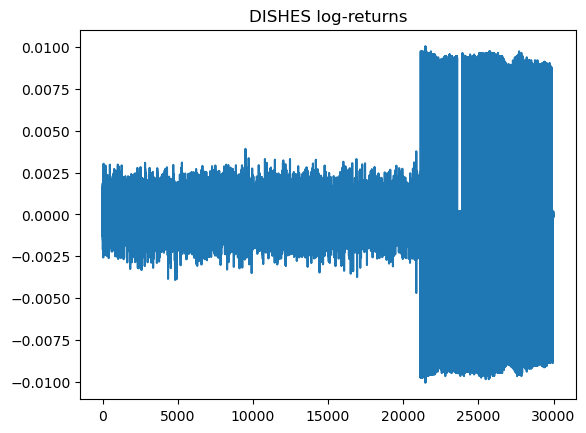

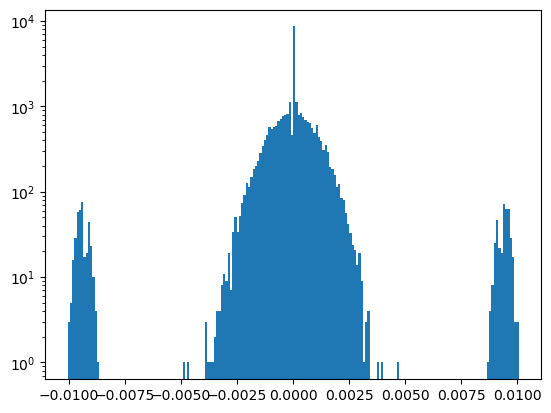

Text(0.5, 1.0, 'Q-Q Plot')

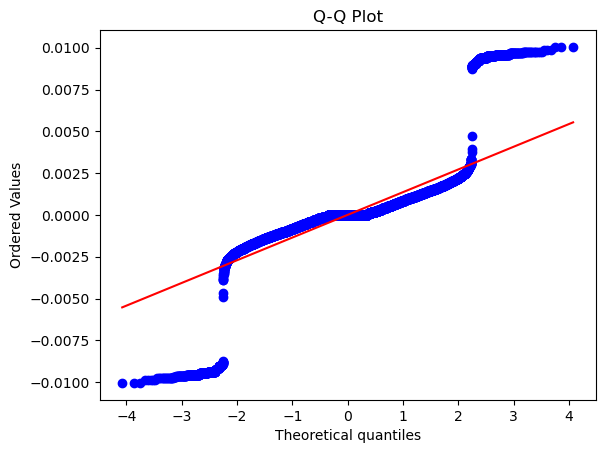

In [11]:
log_ret = np.diff(np.log(bot('DISHES').mid_price))
plt.plot(log_ret)
plt.title('DISHES log-returns')
plt.show()
# Also look at the distribution
plt.hist(log_ret, bins=200)
plt.yscale('log')  # log scale to see tail behavior
plt.show()
stats.probplot(log_ret, dist="norm", plot=plt)
plt.title('Q-Q Plot')

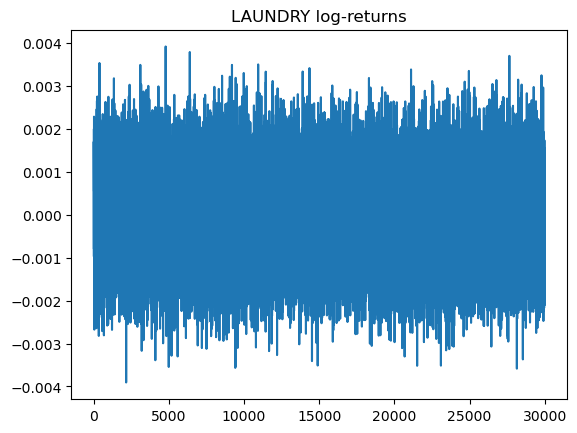

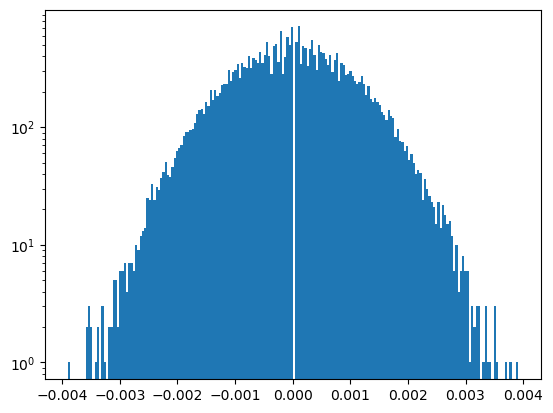

Text(0.5, 1.0, 'Q-Q Plot')

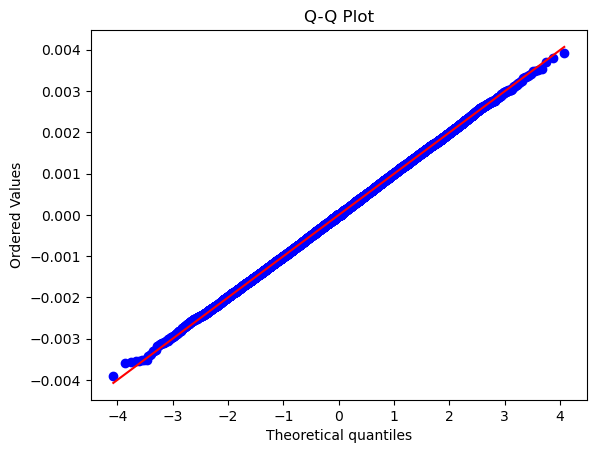

In [12]:
log_ret = np.diff(np.log(bot('LAUNDRY').mid_price))
plt.plot(log_ret)
plt.title('LAUNDRY log-returns')
plt.show()
# Also look at the distribution
plt.hist(log_ret, bins=200)
plt.yscale('log')  # log scale to see tail behavior
plt.show()
stats.probplot(log_ret, dist="norm", plot=plt)
plt.title('Q-Q Plot')

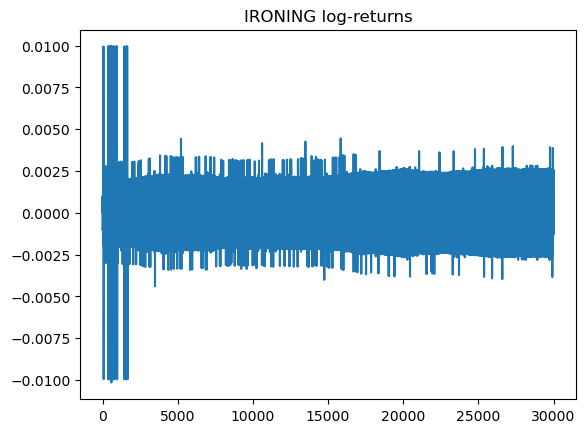

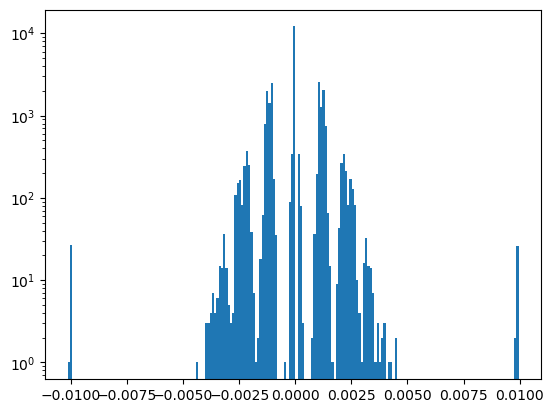

Text(0.5, 1.0, 'Q-Q Plot')

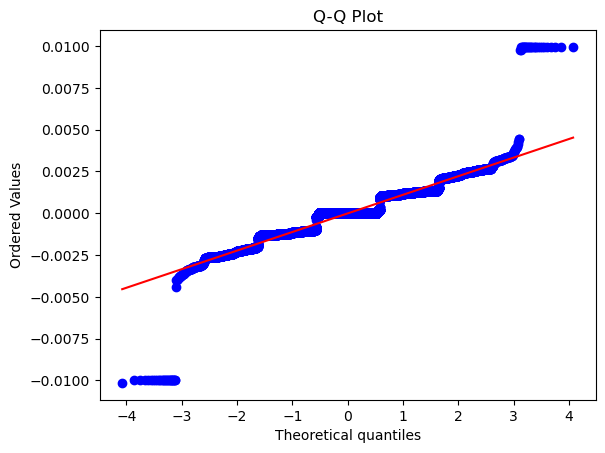

In [13]:
log_ret = np.diff(np.log(bot('IRONING').mid_price))
plt.plot(log_ret)
plt.title('IRONING log-returns')
plt.show()
# Also look at the distribution
plt.hist(log_ret, bins=200)
plt.yscale('log')  # log scale to see tail behavior
plt.show()
stats.probplot(log_ret, dist="norm", plot=plt)
plt.title('Q-Q Plot')

In [17]:
def estimate_gbm_params(prices, dt=1.0):
    """
    prices: price level series
    dt: time step size (1.0 if returns are already per-tick)
    """
    log_ret = np.diff(np.log(prices))
    n = len(log_ret)
    
    # MLE estimates
    mu_ret = np.mean(log_ret)       # mean log-return per tick
    sigma2 = np.var(log_ret, ddof=1) # variance of log-returns
    sigma = np.sqrt(sigma2 / dt)     # volatility per unit time
    
    # Drift of the price process (Ito correction)
    mu = mu_ret / dt + 0.5 * sigma2 / dt  # drift of S, not log(S)
    
    # Standard errors
    se_mu_ret = np.sqrt(sigma2 / n)
    se_sigma = sigma / np.sqrt(2 * (n-1))
    
    # t-stat for drift being nonzero
    t_stat = mu_ret / se_mu_ret
    
    return {
        'mu_log': mu_ret,        # mean log-return per tick
        'mu': mu,                # drift of price process
        'sigma': sigma,          # volatility
        'se_mu': se_mu_ret,      # std error of mean log-return
        'se_sigma': se_sigma,    # std error of sigma
        't_stat_drift': t_stat,  # is drift significantly nonzero?
    }

for asset in chores:
    params = estimate_gbm_params(bot(asset).mid_price)
    print(f"{asset}: mu_log={params['mu_log']:.6f} "
          f"(t={params['t_stat_drift']:.2f}) "
          f"sigma={params['sigma']:.6f}")

VACUUMING: mu_log=-0.000006 (t=-1.09) sigma=0.001006
MOPPING: mu_log=0.000005 (t=0.85) sigma=0.001002
DISHES: mu_log=0.000004 (t=0.38) sigma=0.001703
LAUNDRY: mu_log=-0.000003 (t=-0.45) sigma=0.000998
IRONING: mu_log=-0.000008 (t=-1.20) sigma=0.001177


In [18]:
print('=== Per-flavor stats (levels + log-returns) ===')
for asset in chores:
    tmp = bot(asset).mid_price.dropna()
    log_returns = np.diff(np.log(tmp))
    print(f'\n--- {asset} ---')
    print(f'  ADF levels:        p={adfuller(tmp)[1]:.4f}')
    print(f'  ADF log-returns:   p={adfuller(log_returns)[1]:.4f}')
    lb = acorr_ljungbox(log_returns, lags=[1, 5, 10], return_df=True)
    print(f'  Ljung-Box log-ret: lag1 p={lb.loc[1, "lb_pvalue"]:.4f}, lag5 p={lb.loc[5, "lb_pvalue"]:.4f}, lag10 p={lb.loc[10, "lb_pvalue"]:.4f}')
    print(f'  Hurst levels:      {compute_Hc(tmp.values)[0]:.4f}')
    print(f'  Hurst |log-ret|:   {compute_Hc(np.abs(log_returns) + 1e-12)[0]:.4f}  (vol persistence)')
    print(f'  Skew log-ret:      {stats.skew(log_returns):.4f}')
    print(f'  Excess kurt:       {stats.kurtosis(log_returns):.4f}')
    lag1 = pd.Series(log_returns).autocorr(lag=1)
    print(f'  Lag-1 ACF log-ret: {lag1:+.4f}')


=== Per-flavor stats (levels + log-returns) ===

--- VACUUMING ---
  ADF levels:        p=0.5652
  ADF log-returns:   p=0.0000
  Ljung-Box log-ret: lag1 p=0.1723, lag5 p=0.4271, lag10 p=0.4127
  Hurst levels:      0.4959
  Hurst |log-ret|:   0.0916  (vol persistence)
  Skew log-ret:      -0.0076
  Excess kurt:       0.0192
  Lag-1 ACF log-ret: -0.0079

--- MOPPING ---
  ADF levels:        p=0.5023
  ADF log-returns:   p=0.0000
  Ljung-Box log-ret: lag1 p=0.0357, lag5 p=0.0481, lag10 p=0.0378
  Hurst levels:      0.5330
  Hurst |log-ret|:   0.0967  (vol persistence)
  Skew log-ret:      0.0086
  Excess kurt:       -0.0079
  Lag-1 ACF log-ret: -0.0121

--- DISHES ---
  ADF levels:        p=0.7993
  ADF log-returns:   p=0.0000
  Ljung-Box log-ret: lag1 p=0.0000, lag5 p=0.0000, lag10 p=0.0000
  Hurst levels:      0.4821
  Hurst |log-ret|:   0.0925  (vol persistence)
  Skew log-ret:      0.0455
  Excess kurt:       20.0701
  Lag-1 ACF log-ret: -0.2217

--- LAUNDRY ---
  ADF levels:        p

In [19]:
from statsmodels.stats.diagnostic import het_arch
import warnings
warnings.filterwarnings('ignore')

print('=== KPSS (stationarity around level / trend) ===')
print('  reject (p<0.05) -> NOT stationary; combine with ADF:')
print('    ADF rej + KPSS not rej -> stationary')
print('    ADF not rej + KPSS rej -> non-stationary (random walk)')
print('    ADF rej + KPSS rej -> trend stationary')
for asset in chores:
    tmp = bot(asset).mid_price.dropna()
    kp_lvl = kpss(tmp, regression='c', nlags='auto')[1]
    kp_trend = kpss(tmp, regression='ct', nlags='auto')[1]
    print(f'  {asset}: KPSS level p={kp_lvl:.4f}, KPSS trend p={kp_trend:.4f}')

print()
print('=== ARCH-LM on log-returns (vol clustering / GARCH evidence) ===')
for asset in chores:
    tmp = bot(asset).mid_price.dropna()
    log_returns = np.diff(np.log(tmp))
    lm_stat, lm_p, f_stat, f_p = het_arch(log_returns, nlags=10)
    flag = 'GARCH' if lm_p < 0.05 else ''
    print(f'  {asset}: LM stat={lm_stat:.2f}, p={lm_p:.4f} {flag}')


=== KPSS (stationarity around level / trend) ===
  reject (p<0.05) -> NOT stationary; combine with ADF:
    ADF rej + KPSS not rej -> stationary
    ADF not rej + KPSS rej -> non-stationary (random walk)
    ADF rej + KPSS rej -> trend stationary
  VACUUMING: KPSS level p=0.0100, KPSS trend p=0.0100
  MOPPING: KPSS level p=0.0100, KPSS trend p=0.0100
  DISHES: KPSS level p=0.0100, KPSS trend p=0.0100
  LAUNDRY: KPSS level p=0.0100, KPSS trend p=0.0100
  IRONING: KPSS level p=0.0100, KPSS trend p=0.0100

=== ARCH-LM on log-returns (vol clustering / GARCH evidence) ===
  VACUUMING: LM stat=2.65, p=0.9885 
  MOPPING: LM stat=10.83, p=0.3707 
  DISHES: LM stat=2926.18, p=0.0000 GARCH
  LAUNDRY: LM stat=4.87, p=0.9000 
  IRONING: LM stat=2357.03, p=0.0000 GARCH


In [20]:
from sklearn.decomposition import PCA

log_returns_mat = np.log(mids[robots]).diff().dropna()

print('=== Correlation matrix (log-returns) ===')
print(log_returns_mat.corr().round(3))

print()
print('=== PCA on log-returns ===')
pca = PCA(n_components=5)
pca.fit(log_returns_mat.values)
print(f'Explained variance ratio: {pca.explained_variance_ratio_.round(4)}')
print(f'Cumulative:               {np.cumsum(pca.explained_variance_ratio_).round(4)}')
print()
print('Loadings (rows = PCs, cols = assets):')
loadings = pd.DataFrame(pca.components_, columns=robots, index=[f'PC{i+1}' for i in range(5)])
print(loadings.round(4))

print()
print('=== Cumulative idiosyncratic residual after removing PC1: ADF ===')
print('  (if stationary, that residual is a mean-reverting spread vs market factor)')
pc1_scores = log_returns_mat.values @ pca.components_[0:1].T
reconstructed = pc1_scores @ pca.components_[0:1]
residuals = log_returns_mat.values - reconstructed
res_df = pd.DataFrame(residuals, columns=robots, index=log_returns_mat.index)
for r in robots:
    cum = res_df[r].cumsum()
    p_adf = adfuller(cum)[1]
    flag = 'STATIONARY' if p_adf < 0.05 else ''
    print(f'  {r}: cum residual ADF p={p_adf:.4f} {flag}')


=== Correlation matrix (log-returns) ===
product          ROBOT_VACUUMING  ROBOT_MOPPING  ROBOT_DISHES  ROBOT_LAUNDRY  \
product                                                                        
ROBOT_VACUUMING            1.000         -0.004         0.006         -0.001   
ROBOT_MOPPING             -0.004          1.000        -0.006         -0.010   
ROBOT_DISHES               0.006         -0.006         1.000          0.001   
ROBOT_LAUNDRY             -0.001         -0.010         0.001          1.000   
ROBOT_IRONING              0.014         -0.000         0.001         -0.009   

product          ROBOT_IRONING  
product                         
ROBOT_VACUUMING          0.014  
ROBOT_MOPPING           -0.000  
ROBOT_DISHES             0.001  
ROBOT_LAUNDRY           -0.009  
ROBOT_IRONING            1.000  

=== PCA on log-returns ===
Explained variance ratio: [0.3976 0.1898 0.1389 0.1381 0.1356]
Cumulative:               [0.3976 0.5875 0.7263 0.8644 1.    ]

Loadings (ro

In [21]:
log_returns_mat = np.log(mids[robots]).diff().dropna()
max_lag = 20

print('=== Lead-lag cross-correlation on log-returns ===')
print('  positive k -> A leads B by k ticks; negative k -> B leads A')
print()
for a, b in itertools.combinations(robots, 2):
    xa = log_returns_mat[a].values
    xb = log_returns_mat[b].values
    best_k, best_c = 0, 0.0
    for k in range(-max_lag, max_lag + 1):
        if k == 0:
            continue
        if k > 0:
            c = np.corrcoef(xa[:-k], xb[k:])[0, 1]
        else:
            c = np.corrcoef(xa[-k:], xb[:k])[0, 1]
        if abs(c) > abs(best_c):
            best_k, best_c = k, c
    same = np.corrcoef(xa, xb)[0, 1]
    print(f'  {a} vs {b}: same-tick corr={same:+.4f},  best lag={best_k:+d} corr={best_c:+.4f}')


=== Lead-lag cross-correlation on log-returns ===
  positive k -> A leads B by k ticks; negative k -> B leads A

  ROBOT_VACUUMING vs ROBOT_MOPPING: same-tick corr=-0.0039,  best lag=+17 corr=-0.0196
  ROBOT_VACUUMING vs ROBOT_DISHES: same-tick corr=+0.0059,  best lag=-9 corr=+0.0121
  ROBOT_VACUUMING vs ROBOT_LAUNDRY: same-tick corr=-0.0014,  best lag=+5 corr=-0.0125
  ROBOT_VACUUMING vs ROBOT_IRONING: same-tick corr=+0.0138,  best lag=+17 corr=-0.0124
  ROBOT_MOPPING vs ROBOT_DISHES: same-tick corr=-0.0059,  best lag=-20 corr=+0.0123
  ROBOT_MOPPING vs ROBOT_LAUNDRY: same-tick corr=-0.0096,  best lag=-8 corr=+0.0161
  ROBOT_MOPPING vs ROBOT_IRONING: same-tick corr=-0.0003,  best lag=+10 corr=+0.0136
  ROBOT_DISHES vs ROBOT_LAUNDRY: same-tick corr=+0.0013,  best lag=+12 corr=+0.0143
  ROBOT_DISHES vs ROBOT_IRONING: same-tick corr=+0.0007,  best lag=-11 corr=-0.0152
  ROBOT_LAUNDRY vs ROBOT_IRONING: same-tick corr=-0.0090,  best lag=-19 corr=-0.0122


In [15]:
from statsmodels.tsa.stattools import coint
import itertools
import statsmodels.api as sm

print('=== Pairwise Engle-Granger cointegration ===')
for a, b in itertools.combinations(robots, 2):
    s = mids[[a, b]].dropna()
    p = coint(s[a], s[b])[1]
    flag = 'COINT' if p < 0.05 else ''
    print(f'{a} vs {b}: p={p:.4f} {flag}')

print()
print('=== Pair OLS hedge ratios + ADF on spread ===')
for a, b in itertools.combinations(robots, 2):
    s = mids[[a, b]].dropna()
    X = sm.add_constant(s[b])
    m = sm.OLS(s[a], X).fit()
    beta = m.params.iloc[1]
    intercept = m.params.iloc[0]
    spread = s[a] - beta * s[b] - intercept
    p = adfuller(spread)[1]
    print(f'{a} = {beta:.4f}*{b} + {intercept:.4f}  ADF p={p:.4f}  std={spread.std():.4f}')

=== Pairwise Engle-Granger cointegration ===
ROBOT_VACUUMING vs ROBOT_MOPPING: p=0.2395 
ROBOT_VACUUMING vs ROBOT_DISHES: p=0.0977 
ROBOT_VACUUMING vs ROBOT_LAUNDRY: p=0.0701 
ROBOT_VACUUMING vs ROBOT_IRONING: p=0.2505 
ROBOT_MOPPING vs ROBOT_DISHES: p=0.5754 
ROBOT_MOPPING vs ROBOT_LAUNDRY: p=0.2325 
ROBOT_MOPPING vs ROBOT_IRONING: p=0.2658 
ROBOT_DISHES vs ROBOT_LAUNDRY: p=0.3527 
ROBOT_DISHES vs ROBOT_IRONING: p=0.4999 
ROBOT_LAUNDRY vs ROBOT_IRONING: p=0.2498 

=== Pair OLS hedge ratios + ADF on spread ===
ROBOT_VACUUMING = -0.5484*ROBOT_MOPPING + 15254.1388  ADF p=0.0944  std=330.9135
ROBOT_VACUUMING = -0.6601*ROBOT_DISHES + 15780.0786  ADF p=0.0301  std=389.2079
ROBOT_VACUUMING = 0.6861*ROBOT_LAUNDRY + 2427.6145  ADF p=0.0201  std=329.9444
ROBOT_VACUUMING = 0.5444*ROBOT_IRONING + 4429.3875  ADF p=0.1001  std=332.1056
ROBOT_MOPPING = 0.6052*ROBOT_DISHES + 5036.8682  ADF p=0.3278  std=689.2308
ROBOT_MOPPING = -0.8910*ROBOT_LAUNDRY + 19852.1205  ADF p=0.0908  std=537.5344
ROBOT_MOPP

In [16]:
from statsmodels.tsa.vector_ar.vecm import coint_johansen

print('=== Johansen on all triples ===')
for tri in itertools.combinations(robots, 3):
    sub = mids[list(tri)].dropna()
    res = coint_johansen(sub.values, det_order=0, k_ar_diff=1)
    rej95 = sum(res.lr1 > res.cvt[:, 1])
    rej99 = sum(res.lr1 > res.cvt[:, 2])
    print(f'{tri}')
    print(f'  Trace:     {res.lr1}')
    print(f'  95% crits: {res.cvt[:,1]}')
    print(f'  rej@95: {rej95}, rej@99: {rej99}')
    if rej95 >= 1:
        bn = res.evec[:, 0] / res.evec[0, 0]
        print(f'  First normalized vector: {[f"{x:.4f}" for x in bn]}')
    print()

print('=== Johansen on full 5-asset system ===')
sub = mids[robots].dropna()
res = coint_johansen(sub.values, det_order=0, k_ar_diff=1)
print(f'Eigenvalues: {res.eig}')
print(f'Trace:     {res.lr1}')
print(f'95% crits: {res.cvt[:,1]}')
print(f'99% crits: {res.cvt[:,2]}')
print(f'rej@95: {sum(res.lr1 > res.cvt[:,1])}, rej@99: {sum(res.lr1 > res.cvt[:,2])}')


=== Johansen on all triples ===
('ROBOT_VACUUMING', 'ROBOT_MOPPING', 'ROBOT_DISHES')
  Trace:     [24.34355986  6.0684111   0.67214999]
  95% crits: [29.7961 15.4943  3.8415]
  rej@95: 0, rej@99: 0

('ROBOT_VACUUMING', 'ROBOT_MOPPING', 'ROBOT_LAUNDRY')
  Trace:     [26.27706875 10.37950428  1.23677662]
  95% crits: [29.7961 15.4943  3.8415]
  rej@95: 0, rej@99: 0

('ROBOT_VACUUMING', 'ROBOT_MOPPING', 'ROBOT_IRONING')
  Trace:     [24.35640018  9.48831616  1.64311225]
  95% crits: [29.7961 15.4943  3.8415]
  rej@95: 0, rej@99: 0

('ROBOT_VACUUMING', 'ROBOT_DISHES', 'ROBOT_LAUNDRY')
  Trace:     [24.62945086 11.04703867  0.29440809]
  95% crits: [29.7961 15.4943  3.8415]
  rej@95: 0, rej@99: 0

('ROBOT_VACUUMING', 'ROBOT_DISHES', 'ROBOT_IRONING')
  Trace:     [28.70839323 10.65935452  0.62290573]
  95% crits: [29.7961 15.4943  3.8415]
  rej@95: 0, rej@99: 0

('ROBOT_VACUUMING', 'ROBOT_LAUNDRY', 'ROBOT_IRONING')
  Trace:     [23.99015427  8.77083989  0.70700069]
  95% crits: [29.7961 15.4

# In Conclusion
IRONING and DISHES are subject to (seemingly random, unless someone can find a catalyst?) regime changes. The QQ-plots show that the log returns for the other assets are perfect normal distributions which confirms that they are GBMs. I actually want to test this for the microchips dataset as well.  
\\  
I ran the same code as above on the microchips and those are all GBMs.  
\\  
Claude now suggests running cointegration and/or PCA methods on these. I think Claude is right in saying that some linear combination of the assets in this and the microchip class will be arb-able
\\
No cointegration on pairs and triplets. 

PCA did not explain variance. 
\\
WE CAN TRADE SHOCKS OF DISHES AND IRONING!

